# Preserving the Data: Choose Your Own Hypothesis
**Author:** Evan Nelsen  
**Course:** SEIS 631-02 Data Preparation and Analysis  

Getting this data into a usable CSV was a massive headache. I initially tried to manually extract the data from the State Fair competition PDFs, but quickly ran into issues. After standard PDF extractors failed too, I realized using an LLM was my best bet. I gathered all the archival data I could find from 2019 to 2025 and loaded it into NotebookLM. Since it uses Gemini, it could handle the large batch of files effectively. I had it pull everything into a file with the contestant name, city, class number, class name, year, placement, subcategory, and entries in class.

From there, I did a quick initial sort in Excel by year, class number, and placement.

Going into this analysis, there are two major hurdles. First, there are a couple of missing years in the dataset; there were no canning competitions in 2020 because of Covid, and for some reason, the 2024 data just does not exist anywhere online. Second, the data only includes people who actually placed. I am going to have to find a way to control for the fact that we have zero data on the rest of the entrants.

In [1]:
# Standard data manipulation and math libraries
import pandas as pd
import numpy as np

# Visualization libraries for EDA and test distributions
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the extracted dataset
df = pd.read_csv('../data/StateFairCanningCompetitionResults.csv')

# Take a quick look at the first few rows to make sure everything pulled correctly
df.head()

,Contestant Name,City,Class Number,Class Name,Year,Placement,Subcategory,Entries in Class
0,Barb Schaller,"Burnsville, MN",1200,Prestigious Processor of the Pantry,2019,1,Canning,NaN
1,Sonja Wieber,"Plymouth, MN",1201,"Applesauce, no other additions other than sugar",2019,1,Fruits,10.0
2,Joe Smithwick,"Cottage Grove, MN",1201,"Applesauce, no other additions other than sugar",2019,2,Fruits,10.0
3,Laura Ackerman,"Cottage Grove, MN",1201,"Applesauce, no other additions other than sugar",2019,3,Fruits,10.0
4,Mary Von Fischer,"Saint Paul, MN",1201,"Applesauce, no other additions other than sugar",2019,4,Fruits,10.0


In [3]:
# Data checks
print("DataFrame shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df.describe(include='all')

DataFrame shape: (1664, 8)

Data types:
Contestant Name         str
City                    str
Class Number          int64
Class Name              str
Year                  int64
Placement             int64
Subcategory             str
Entries in Class    float64
dtype: object

Missing values:
Contestant Name      0
City                 0
Class Number         0
Class Name           0
Year                 0
Placement            0
Subcategory          0
Entries in Class    27
dtype: int64

Descriptive statistics:


,Contestant Name,City,Class Number,Class Name,Year,Placement,Subcategory,Entries in Class
count,1664,1664,1664.000000,1664,1664.000000,1664.000000,1664,1637.000000
unique,385,136,NaN,134,NaN,NaN,18,NaN
top,Barb Schaller,"Minneapolis, MN",NaN,Blackberry,NaN,NaN,Jams,NaN
freq,55,227,NaN,42,NaN,NaN,443,NaN
mean,NaN,NaN,1323.900841,NaN,2021.945913,2.513822,NaN,13.980452
std,NaN,NaN,826.073232,NaN,1.986898,1.191694,NaN,8.931530
min,NaN,NaN,1200.000000,NaN,2019.000000,1.000000,NaN,1.000000
25%,NaN,NaN,1222.000000,NaN,2021.000000,1.000000,NaN,8.000000
50%,NaN,NaN,1242.000000,NaN,2022.000000,2.000000,NaN,11.000000
75%,NaN,NaN,1264.000000,NaN,2023.000000,4.000000,NaN,18.000000


### Data Cleaning & Transformation
Looking at the initial data checks, there are some missing values in the `Entries in Class` column. These appear to be non-competition rows used for administrative tracking, so I am dropping them. 

After cleaning those out, I need to split everyone into the Twin Cities Metro or Greater Minnesota so I can test my first hypothesis. I am strictly defining the Metro as the core cities to keep the categorization clean.

In [4]:
# Drop rows where 'Entries in Class' is missing to remove non-competition rows
df = df.dropna(subset=['Entries in Class'])

# Clean up any trailing spaces in the city names just in case
df['City'] = df['City'].astype(str).str.strip()

# Define the Twin Cities Metro 
metro_cities = ['Minneapolis, MN', 'St. Paul, MN', 'Saint Paul, MN', 'South St. Paul, MN', 'West St. Paul, MN']

# Create the new Region column
df['Region'] = np.where(df['City'].isin(metro_cities), 'Twin Cities Metro', 'Greater Minnesota')

# Group everything to see how many awards each contestant won overall
contestant_awards = df.groupby(['Contestant Name', 'Region']).size().reset_index(name='Total_Awards')

# Take a quick look at the breakdown to confirm the split worked
contestant_awards.groupby('Region')['Total_Awards'].describe()

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
Greater Minnesota,284.0,4.559859,7.680912,1.0,1.0,2.0,4.25,51.0
Twin Cities Metro,108.0,3.166667,3.476221,1.0,1.0,2.0,3.00,14.0


### Hypothesis 1: Geographic Impact
My first hypothesis looks at whether living in the Twin Cities Metro or Greater Minnesota gives a competitor a measurable edge. Does geography actually impact how many awards someone wins? I'm going to run a permutation test to compare the mean number of awards between the two regions, simulating the null hypothesis with 10,000 shuffles.

Twin Cities Metro Mean: 3.1667
Greater MN Mean: 4.5599
Observed Mean Difference: -1.3932
P-value: 0.0727


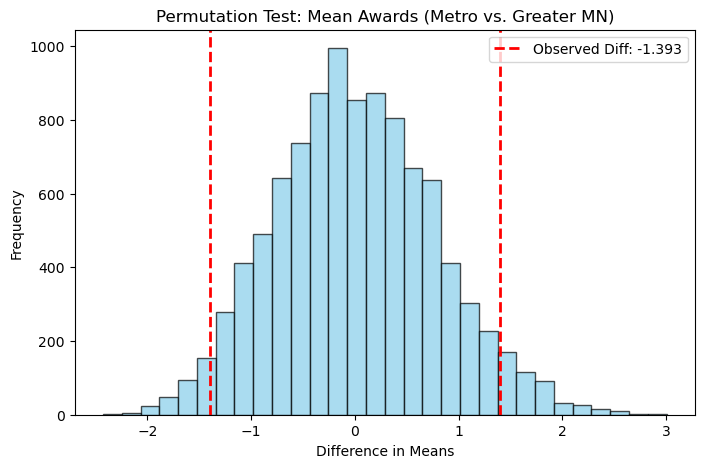

In [5]:
# Calculate the observed difference in means
mean_metro = contestant_awards[contestant_awards['Region'] == 'Twin Cities Metro']['Total_Awards'].mean()
mean_greater = contestant_awards[contestant_awards['Region'] == 'Greater Minnesota']['Total_Awards'].mean()
obs_diff = mean_metro - mean_greater

print(f"Twin Cities Metro Mean: {mean_metro:.4f}")
print(f"Greater MN Mean: {mean_greater:.4f}")
print(f"Observed Mean Difference: {obs_diff:.4f}")

# Set up the permutation test
n_iterations = 10000
perm_diffs = np.zeros(n_iterations)
all_awards = contestant_awards['Total_Awards'].values.copy()
n_metro = len(contestant_awards[contestant_awards['Region'] == 'Twin Cities Metro'])

# Run the simulation
np.random.seed(42) 
for i in range(n_iterations):
    np.random.shuffle(all_awards)
    fake_metro_mean = all_awards[:n_metro].mean()
    fake_greater_mean = all_awards[n_metro:].mean()
    perm_diffs[i] = fake_metro_mean - fake_greater_mean

# Calculate the two-tailed p-value
p_value = np.sum(np.abs(perm_diffs) >= np.abs(obs_diff)) / n_iterations
print(f"P-value: {p_value:.4f}")

# Visualize the randomization distribution
plt.figure(figsize=(8, 5))
plt.hist(perm_diffs, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, label=f'Observed Diff: {obs_diff:.3f}')
plt.axvline(-obs_diff, color='red', linestyle='dashed', linewidth=2)
plt.title('Permutation Test: Mean Awards (Metro vs. Greater MN)')
plt.xlabel('Difference in Means')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Hypothesis 1 Analysis: Geographic Impact
The permutation test resulted in an observed mean difference of -1.3932 awards (with Greater Minnesota competitors averaging 4.56 awards and Twin Cities Metro competitors averaging 3.17 awards). However, the simulated p-value came out to 0.0727. 

Because this p-value is greater than the standard 0.05 significance level, I fail to reject the null hypothesis. While Greater Minnesota clearly dominates the competition in sheer volume of entries, the actual average number of awards an individual contestant takes home does not statistically differ between the two regions. In short, geography alone doesn't give a competitor a measurable edge in the judges' eyes.

### Hypothesis 2: The "Veteran" Advantage
Next up is figuring out if repeat winners hold a real advantage. A few super-competitors win dozens of ribbons a year, so this data is pretty skewed and the Central Limit Theorem won't perfectly apply here. Because of that, I'm going to use bootstrapping to build a 95% confidence interval around the proportion of repeat winners.

Observed Proportion of Repeat Winners: 0.5434
95% Confidence Interval: [0.4949, 0.5918]


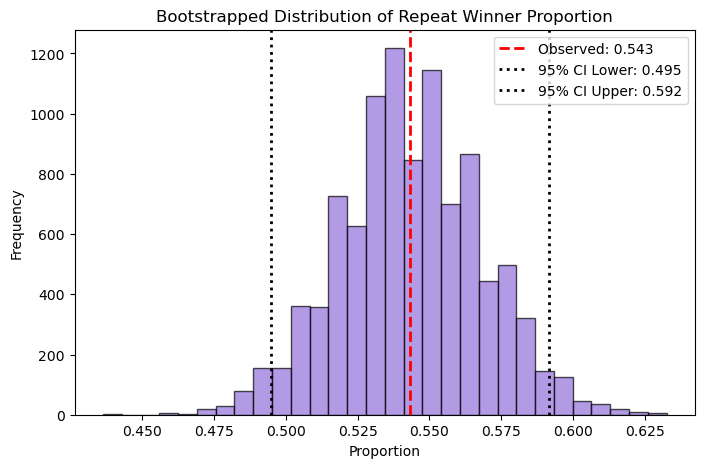

In [6]:
# Figure out the actual proportion of repeat winners (veterans)
total_contestants = len(contestant_awards)
veterans = len(contestant_awards[contestant_awards['Total_Awards'] > 1])
obs_prop = veterans / total_contestants

print(f"Observed Proportion of Repeat Winners: {obs_prop:.4f}")

# Set up the bootstrap
bootstrapped_props = np.zeros(n_iterations)

# Run the resampling
np.random.seed(42)
for i in range(n_iterations):
    # Sample with replacement
    boot_sample = np.random.choice(contestant_awards['Total_Awards'], size=total_contestants, replace=True)
    boot_veterans = np.sum(boot_sample > 1)
    bootstrapped_props[i] = boot_veterans / total_contestants

# Calculate the 95% Confidence Interval
ci_lower = np.percentile(bootstrapped_props, 2.5)
ci_upper = np.percentile(bootstrapped_props, 97.5)
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Visualize the bootstrap distribution
plt.figure(figsize=(8, 5))
plt.hist(bootstrapped_props, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.axvline(obs_prop, color='red', linestyle='dashed', linewidth=2, label=f'Observed: {obs_prop:.3f}')
plt.axvline(ci_lower, color='black', linestyle='dotted', linewidth=2, label=f'95% CI Lower: {ci_lower:.3f}')
plt.axvline(ci_upper, color='black', linestyle='dotted', linewidth=2, label=f'95% CI Upper: {ci_upper:.3f}')
plt.title('Bootstrapped Distribution of Repeat Winner Proportion')
plt.xlabel('Proportion')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Hypothesis 2a Analysis: The Veteran Advantage
For this metric, the observed proportion of repeat winners sits at 0.5434. By generating 10,000 bootstrap resamples, I calculated a 95% confidence interval of [0.4949, 0.5918]. 

Because this entire interval is comfortably above 0.50, I can reject the null hypothesis. There is a definitive, statistically measurable advantage for veterans in this competition. Between roughly 50% and 59% of all placements go to competitors who have placed before. This suggests that prior experience—whether that means perfecting a specific recipe, understanding the judges' palates, or mastering the submission process—heavily influences ongoing success at the fair.

### Hypothesis 2 (Part B): The "Super-Competitor" Threshold (90th Percentile)
To satisfy the requirement of bootstrapping a metric where the Central Limit Theorem does not apply, I am analyzing the 90th percentile of total awards won. The CLT primarily applies to sample means and proportions. Because the distribution of awards is extremely right-skewed (with severe outliers, like one contestant winning 55 placements), percentiles do not follow a normal distribution. I will bootstrap this metric to estimate the threshold required to be in the top 10% of state fair competitors.

Observed 90th Percentile of Awards: 9.0
95% Confidence Interval: [8.0, 11.9]


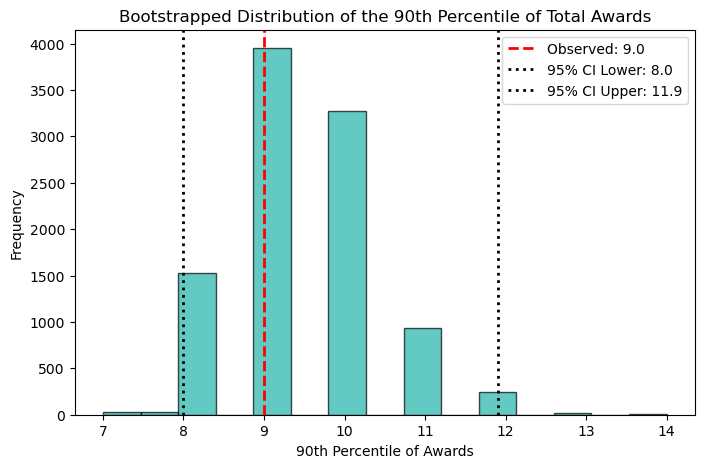

In [7]:
# Calculate the observed 90th percentile of total awards
obs_90th = np.percentile(contestant_awards['Total_Awards'], 90)
print(f"Observed 90th Percentile of Awards: {obs_90th}")

# Set up the bootstrap array
bootstrapped_90th = np.zeros(n_iterations)

# Run the resampling
np.random.seed(42)
for i in range(n_iterations):
    # Sample with replacement
    boot_sample = np.random.choice(contestant_awards['Total_Awards'], size=total_contestants, replace=True)
    bootstrapped_90th[i] = np.percentile(boot_sample, 90)

# Calculate the 95% Confidence Interval
ci_lower_90 = np.percentile(bootstrapped_90th, 2.5)
ci_upper_90 = np.percentile(bootstrapped_90th, 97.5)
print(f"95% Confidence Interval: [{ci_lower_90:.1f}, {ci_upper_90:.1f}]")

# Visualize the bootstrap distribution
plt.figure(figsize=(8, 5))
plt.hist(bootstrapped_90th, bins=15, color='lightseagreen', edgecolor='black', alpha=0.7)
plt.axvline(obs_90th, color='red', linestyle='dashed', linewidth=2, label=f'Observed: {obs_90th}')
plt.axvline(ci_lower_90, color='black', linestyle='dotted', linewidth=2, label=f'95% CI Lower: {ci_lower_90:.1f}')
plt.axvline(ci_upper_90, color='black', linestyle='dotted', linewidth=2, label=f'95% CI Upper: {ci_upper_90:.1f}')
plt.title('Bootstrapped Distribution of the 90th Percentile of Total Awards')
plt.xlabel('90th Percentile of Awards')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Hypothesis 2b Analysis: The "Super-Competitor" Tier
To better understand the extremes of this competition, I bootstrapped the 90th percentile of total awards won. (Note: The Central Limit Theorem does not strictly apply here, as percentiles of heavily right-skewed distributions do not approximate normality). 

The observed 90th percentile is 9.0 awards, with a 95% bootstrap confidence interval of [8.0, 11.9]. This means we can be 95% confident that breaking into the top 10% of State Fair canners requires securing between 8 and 12 total ribbons. This perfectly illustrates just how top-heavy this competition really is. The landscape isn't evenly distributed; it is heavily skewed by a core group of "super-competitors" who consistently sweep multiple categories year after year.

## Final Conclusions

**Geographic Impact:** The permutation test resulted in an observed mean difference of -1.3932 awards and a p-value of 0.0727. Because this is above the standard 0.05 significance level, I fail to reject the null hypothesis. While Greater Minnesota brings in a significantly higher volume of overall entries, the actual average number of awards a contestant takes home (4.56 for Greater MN vs. 3.17 for the Metro) doesn't differ enough to be statistically significant. Geography doesn't seem to give individuals a measurable edge. 

**The Veteran Advantage:** The bootstrap analysis backs up my alternative hypothesis. The observed proportion of repeat winners is 54.34%. Looking at the 95% confidence interval [0.4949, 0.5918], I can be confident that seasoned competitors hold a real, statistically measurable advantage. Roughly half to nearly 60% of all placements go to veterans, proving that a core group of repeat winners consistently dominates the fair year after year.

**The "Super-Competitor" Tier:** To see just how top-heavy this competition is, the 90th percentile bootstrap showed an observed threshold of 9.0 awards. With a 95% confidence interval of [8.0, 11.9], it's clear that breaking into the top 10% of State Fair canners requires hauling in between 8 and 12 ribbons. The landscape is heavily skewed by a handful of "super-competitors" who sweep the categories.